# 06C — Base Marketing Mix Model (MMM)

---

## What is this notebook?

- This is the **base model** — a simplified, clean starting point for measuring how media spending impacts Club Piscine's revenue
- It's intentionally minimal: we want to understand the fundamentals before adding complexity
- Every cell does one thing and is explained in plain language so we can walk through it together with the client

## What does the model do?

- **Step 1**: Separate out the seasonal pattern (pools sell in summer — that's not because of advertising)
- **Step 2**: Measure what's left over and ask: how much of that is explained by media spending?
- The result: a ROAS (Return on Ad Spend) estimate for each of the 7 media channels, plus confidence intervals telling us how sure we are

## Structure (each cell = one step)

- **Cells 1–2**: Load data, define all parameters in one place
- **Cells 3–4**: Transform the spend data (adstock = carryover over time, saturation = diminishing returns)
- **Cell 5**: Build the feature matrices for both stages
- **Cell 6**: Stage 1 — fit the seasonal baseline
- **Cell 7**: Stage 2 — fit media effects on the residuals (Ridge regression)
- **Cell 8**: Convert coefficients to ROAS and media contribution %
- **Cell 9**: Bootstrap confidence intervals (how reliable are these numbers?)
- **Cells 10–11**: Diagnostics and sensitivity analysis
- **Cells 12–13**: Final summary, export, and charts

## Key decisions in this base model

- **TV decay raised from 0.2 to 0.5** — the previous notebook treated TV like a short-term channel, but the client's own strategy says TV is for brand-building (longer memory)
- **No forced non-negativity** — if a channel shows a negative coefficient, we want to see it honestly rather than masking it
- **Ridge regression** — prevents overfitting given we only have 36 months of data
- **Hill saturation for all channels** — consistent, industry-standard approach to diminishing returns

---
## Cell 1 — Load the Data

- We're loading the merged dataset that was built in earlier notebooks (NB01–05)
- It contains 36 monthly rows (3 fiscal years: FY2023–FY2025), with revenue, media spend by channel, and weather data
- This is the same data used in NB06 and NB06B — nothing new here, just loading it cleanly

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# --- Paths ---
project_root = Path('.').resolve().parent
data_dir = project_root / 'data' / 'processed'
fig_dir = project_root / 'reports' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# --- Load the merged dataset (sales + spend + weather, 36 rows × 43 cols) ---
df = pd.read_csv(data_dir / 'sales_spend_weather.csv')
print(f"Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Total revenue (3Y): ${df['total_all_revenue'].sum():,.0f}")
print(f"Total media spend (3Y): ${df['spend_total'].sum():,.0f}")
df.head(3)

Dataset: 36 rows × 43 columns
Date range: 2022-11-01 to 2025-10-01
Total revenue (3Y): $512,411,602
Total media spend (3Y): $9,412,690


,year,month_num,piscines_hors_terre_units,piscines_hors_terre_revenue,piscines_creusees_units,piscines_creusees_revenue,spas_units,spas_revenue,meubles_gazebo_revenue,fitness_revenue,...,heating_degree_days,cooling_degree_days,rolling_temp_7d_eom,n_holidays,holiday_end_season,holiday_low,holiday_peak,holiday_pool_closing,holiday_pool_opening,holiday_spring_start
0,2023,11,118,580442,12,348768,134.0,1442912,722398.0,334203.0,...,418.8,0.0,1.04,0,0,0,0,0,0,0
1,2023,12,66,324654,6,174384,62.0,667616,315901.0,308733.0,...,619.9,0.0,-2.00,2,0,1,0,0,0,0
2,2023,1,308,1515052,18,523152,118.0,1270624,748026.0,752187.0,...,720.8,0.0,-8.90,2,0,1,0,0,0,0


---
## Cell 2 — Define All Parameters

- Everything the model needs is defined here in ONE place — channels, decay rates, saturation settings
- If you want to change an assumption, this is the only cell you need to touch
- **Important change vs NB06**: TV decay rate is now 0.5 (was 0.2). The client's media strategy describes TV as "brand rebuilding" with "halo effects" — that's a long-term effect, not a 2-week flash. Industry literature backs this up (λ=0.5–0.9 for brand TV)

In [2]:
# ============================================================
# TARGET
# ============================================================
TARGET = 'total_all_revenue'

# ============================================================
# 7 MEDIA CHANNELS (consolidated from raw budget data)
# ============================================================
CHANNELS = [
    'spend_television',
    'spend_radio',
    'spend_panneaux',
    'spend_social_media',
    'spend_preroll',
    'spend_banniere_web',
    'spend_circulaire_digitale',
]

CHANNEL_LABELS = {
    'spend_television': 'Television',
    'spend_radio': 'Radio',
    'spend_panneaux': 'Panneaux (DOOH)',
    'spend_social_media': 'Social Media',
    'spend_preroll': 'Preroll (Video)',
    'spend_banniere_web': 'Web Banners',
    'spend_circulaire_digitale': 'Digital Flyers',
}

# ============================================================
# ADSTOCK DECAY RATES (λ)
# Higher λ = longer carryover. Half-life = log(0.5)/log(λ) months.
#
# Rationale: Client narrative says TV is for "brand rebuilding" and
# "halo effects" — these are long-term effects. Industry literature
# recommends λ=0.5–0.9 for brand TV.
# ============================================================
DECAY_RATES = {
    'spend_television':          0.5,   # Was 0.2 in NB06. Brand TV = longer memory
    'spend_radio':               0.5,   # Tactical but repeated. 1-month half-life
    'spend_panneaux':            0.4,   # OOH/DOOH, moderate carryover
    'spend_social_media':        0.1,   # Digital, immediate response
    'spend_preroll':             0.3,   # Video, moderate carryover
    'spend_banniere_web':        0.2,   # Display, short carryover
    'spend_circulaire_digitale': 0.3,   # Digital flyers, moderate (promo-driven)
}

# ============================================================
# SATURATION PARAMETERS (Hill function for all channels)
# K = half-saturation point. Set to 70% of max observed spend.
# alpha = 2 (standard steepness)
# ============================================================
SATURATION_ALPHA = 2  # Same for all channels (parsimony with N=36)

# K will be computed dynamically from the data in Cell 4
K_FRACTION = 0.7  # K = 70% of max observed adstocked spend

# ============================================================
# SEASONALITY CONTROLS (Fourier terms)
# 1st harmonic captures the annual cycle (peak summer, trough winter)
# ============================================================
FOURIER_ORDER = 1  # sin + cos of annual frequency (2 terms)

# ============================================================
# WEATHER CONTROLS
# ============================================================
WEATHER_FEATURES = ['avg_temp_mean', 'total_precipitation']

# Print summary
print("=" * 60)
print("MODEL PARAMETERS")
print("=" * 60)
print(f"Target: {TARGET}")
print(f"Channels: {len(CHANNELS)}")
print(f"Seasonality: Fourier order {FOURIER_ORDER} ({FOURIER_ORDER * 2} terms)")
print(f"Weather controls: {WEATHER_FEATURES}")
print(f"Saturation: Hill (α={SATURATION_ALPHA}), K = {K_FRACTION:.0%} of max adstocked spend")
print()
for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    lam = DECAY_RATES[ch]
    hl = np.log(0.5) / np.log(lam) if 0 < lam < 1 else 0
    print(f"  {label:<20s}  λ={lam:.1f}  half-life={hl:.1f} months")

MODEL PARAMETERS
Target: total_all_revenue
Channels: 7
Seasonality: Fourier order 1 (2 terms)
Weather controls: ['avg_temp_mean', 'total_precipitation']
Saturation: Hill (α=2), K = 70% of max adstocked spend

  Television            λ=0.5  half-life=1.0 months
  Radio                 λ=0.5  half-life=1.0 months
  Panneaux (DOOH)       λ=0.4  half-life=0.8 months
  Social Media          λ=0.1  half-life=0.3 months
  Preroll (Video)       λ=0.3  half-life=0.6 months
  Web Banners           λ=0.2  half-life=0.4 months
  Digital Flyers        λ=0.3  half-life=0.6 months


---
## Cell 3 — Adstock (Carryover Effect)

- Advertising doesn't just work the day it airs — a TV ad in March still has some effect in April
- Adstock models this: each month's spend gets "carried over" into the next month, but smaller each time
- The decay rate (λ) controls how fast it fades: λ=0.5 means 50% carries over, λ=0.1 means only 10%
- Formula: `Adstock_this_month = Spend_this_month + λ × Adstock_last_month`
- Below we show a before/after example for TV so you can see it in action

In [3]:
def geometric_adstock(x, decay_rate):
    """Adstock_t = x_t + λ * Adstock_{t-1}"""
    x = np.asarray(x, dtype=float)
    adstocked = np.zeros_like(x)
    adstocked[0] = x[0]
    for t in range(1, len(x)):
        adstocked[t] = x[t] + decay_rate * adstocked[t - 1]
    return adstocked


# Apply adstock to each channel
for ch in CHANNELS:
    lam = DECAY_RATES[ch]
    df[f'{ch}_adstock'] = geometric_adstock(df[ch].fillna(0).values, lam)

# Show before/after for TV as example
print("Example: Television adstock (first 6 months of FY2023)")
print(f"{'Month':<12} {'Raw Spend':>12} {'Adstocked':>12}")
print("-" * 40)
for i in range(6):
    m = df.iloc[i]['month']
    raw = df.iloc[i]['spend_television']
    ads = df.iloc[i]['spend_television_adstock']
    print(f"{m:<12} ${raw:>11,.0f} ${ads:>11,.0f}")

Example: Television adstock (first 6 months of FY2023)
Month           Raw Spend    Adstocked
----------------------------------------
Novembre     $          0 $          0
Décembre     $          0 $          0
Janvier      $          0 $          0
Février      $    147,872 $    147,872
Mars         $    184,066 $    258,002
Avril        $    368,584 $    497,585


---
## Cell 4 — Saturation (Diminishing Returns)

- Spending $50K on TV gets you a lot of awareness. Spending another $50K on top of that? Less additional impact. That's diminishing returns
- The Hill function models this: it takes the adstocked spend and squishes it into a 0-to-1 scale
- **K** = the half-saturation point. When spend hits K, you're at 50% of the maximum possible effect. We set K at 70% of each channel's peak observed spend
- **α = 2** = the steepness of the curve (standard value, same for all channels to keep things simple)
- This is the industry-standard approach used in most MMMs

In [4]:
def hill_saturation(x, K, alpha=2):
    """y = x^α / (x^α + K^α). Output in [0, 1]."""
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x**alpha / (x**alpha + K**alpha), 0.0)


# Compute K for each channel (70% of max adstocked spend)
K_VALUES = {}
for ch in CHANNELS:
    adstock_col = f'{ch}_adstock'
    max_adstocked = df[adstock_col].max()
    K_VALUES[ch] = K_FRACTION * max_adstocked

# Apply Hill saturation to each channel
for ch in CHANNELS:
    adstock_col = f'{ch}_adstock'
    K = K_VALUES[ch]
    df[f'{ch}_saturated'] = hill_saturation(df[adstock_col].values, K, SATURATION_ALPHA)

# Print K values
print("Half-saturation points (K):")
print(f"{'Channel':<25} {'K ($)':>12} {'Max Adstocked ($)':>18}")
print("-" * 58)
for ch in CHANNELS:
    label = CHANNEL_LABELS[ch]
    K = K_VALUES[ch]
    mx = df[f'{ch}_adstock'].max()
    print(f"{label:<25} ${K:>11,.0f} ${mx:>17,.0f}")

Half-saturation points (K):
Channel                          K ($)  Max Adstocked ($)
----------------------------------------------------------
Television                $    484,577 $          692,252
Radio                     $    187,275 $          267,536
Panneaux (DOOH)           $     58,418 $           83,454
Social Media              $     35,495 $           50,706
Preroll (Video)           $     58,232 $           83,189
Web Banners               $     55,720 $           79,600
Digital Flyers            $     36,775 $           52,536


---
## Cell 5 — Build the Two Feature Sets

We split the model into two stages, so we need two sets of features:

- **Stage 1 (seasonality + weather)**: Fourier terms to capture the annual cycle (summer peak / winter trough) + average temperature and precipitation. These explain the natural rhythm of the business — people buy pools when it's warm, not because of an ad
- **Stage 2 (media)**: The 7 saturated media channel variables from the previous cell. This is what we actually want to measure

We also print the observation-to-parameter ratio here — it tells us how much data we have relative to the number of things we're estimating. Below 5:1 means we need to be careful (and we are, with Ridge).

In [5]:
# --- Target ---
y = df[TARGET].values
n = len(y)

# --- Stage 1: Seasonality + Weather ---
# Fourier terms for annual seasonality
t = np.arange(n)
period = 12  # 12 months = 1 year

X1_dict = {}
for k in range(1, FOURIER_ORDER + 1):
    X1_dict[f'sin_{k}'] = np.sin(2 * np.pi * k * t / period)
    X1_dict[f'cos_{k}'] = np.cos(2 * np.pi * k * t / period)

# Weather
for wf in WEATHER_FEATURES:
    X1_dict[wf] = df[wf].values

X1 = pd.DataFrame(X1_dict)

# --- Stage 2: Media (saturated) ---
media_cols = [f'{ch}_saturated' for ch in CHANNELS]
X2 = df[media_cols].copy()
X2.columns = [CHANNEL_LABELS[ch] for ch in CHANNELS]  # Readable names

print(f"Stage 1 features ({X1.shape[1]}): {list(X1.columns)}")
print(f"Stage 2 features ({X2.shape[1]}): {list(X2.columns)}")
print(f"Target: {TARGET} (n={n})")
print(f"\nTotal parameters to estimate: {X1.shape[1] + X2.shape[1] + 2} (incl. 2 intercepts)")
print(f"Observations-to-parameter ratio: {n / (X1.shape[1] + X2.shape[1] + 2):.1f}:1")

Stage 1 features (4): ['sin_1', 'cos_1', 'avg_temp_mean', 'total_precipitation']
Stage 2 features (7): ['Television', 'Radio', 'Panneaux (DOOH)', 'Social Media', 'Preroll (Video)', 'Web Banners', 'Digital Flyers']
Target: total_all_revenue (n=36)

Total parameters to estimate: 13 (incl. 2 intercepts)
Observations-to-parameter ratio: 2.8:1


---
## Cell 6 — Stage 1: Remove the Seasonal Pattern

This is the critical first step, and here's why:

- Club Piscine sells pools, spas, and outdoor furniture. Revenue naturally peaks in summer and drops in winter — that's just the nature of the business
- The media budget also peaks in summer (you advertise when people are buying)
- If we don't separate these two, the model would give media credit for summer demand that would have happened anyway
- So we first fit a simple model that captures the seasonal pattern + weather, then look at the **residuals** — the revenue that season and weather can't explain
- Those residuals are what media needs to account for
- The chart below shows: left = how well the seasonal model fits, right = the residuals (gaps the model doesn't explain)

Stage 1 — Seasonality Baseline
  R² = 0.849  (84.9% of revenue variance explained by season + weather)
  Residual std = $3,696,812/month
  Mean revenue = $14,233,656/month
  Residuals represent the 15.1% that media channels need to explain.


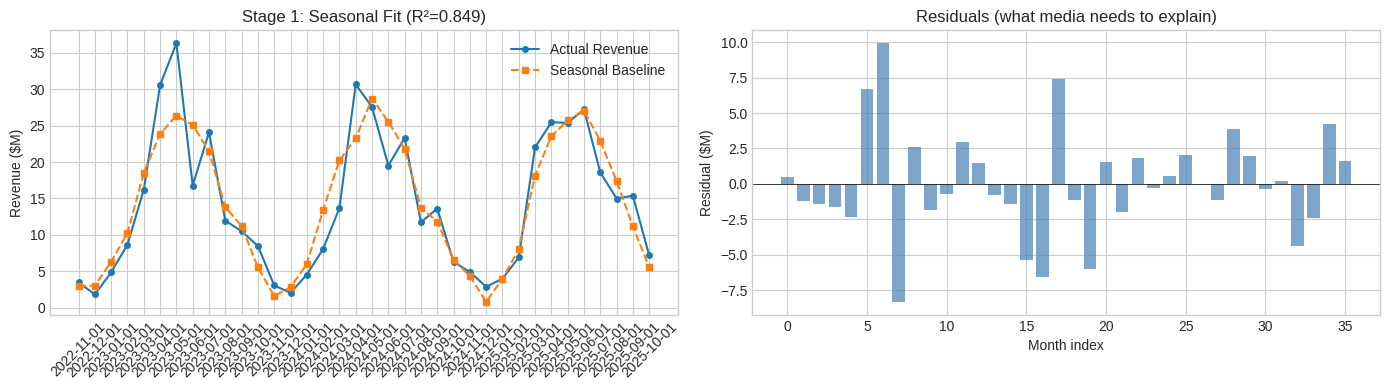

In [6]:
# Scale features for Stage 1
scaler_1 = StandardScaler()
X1_scaled = scaler_1.fit_transform(X1)

# Fit OLS (no regularization needed for 4 controls with n=36)
from sklearn.linear_model import LinearRegression
stage1 = LinearRegression()
stage1.fit(X1_scaled, y)

# Predictions and residuals
y_pred_s1 = stage1.predict(X1_scaled)
residuals = y - y_pred_s1

# Metrics
r2_s1 = r2_score(y, y_pred_s1)
print(f"Stage 1 — Seasonality Baseline")
print(f"  R² = {r2_s1:.3f}  ({r2_s1*100:.1f}% of revenue variance explained by season + weather)")
print(f"  Residual std = ${np.std(residuals):,.0f}/month")
print(f"  Mean revenue = ${np.mean(y):,.0f}/month")
print(f"  Residuals represent the {(1-r2_s1)*100:.1f}% that media channels need to explain.")

# Quick visual
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['date'], y / 1e6, 'o-', label='Actual Revenue', markersize=4)
axes[0].plot(df['date'], y_pred_s1 / 1e6, 's--', label='Seasonal Baseline', markersize=4)
axes[0].set_ylabel('Revenue ($M)')
axes[0].set_title(f'Stage 1: Seasonal Fit (R²={r2_s1:.3f})')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(range(n), residuals / 1e6, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Residual ($M)')
axes[1].set_title('Residuals (what media needs to explain)')
axes[1].set_xlabel('Month index')

plt.tight_layout()
plt.savefig(fig_dir / '06c_stage1_fit.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 7 — Stage 2: Measure Media Effects (Ridge Regression)

Now we take the residuals from Stage 1 and ask: can media spending explain any of that remaining variance?

- We use **Ridge regression** because we only have 36 data points for 7 channels — plain regression would overfit
- Ridge adds a penalty (controlled by **alpha**) that keeps coefficients from getting too extreme
- **Important nuance**: Cross-validation picks alpha to minimize prediction error. But we're not trying to predict — we're trying to measure causal media effects. These are different goals
- With residuals centered near zero, the "best prediction" is basically "predict zero" — which means the highest alpha wins CV every time. That's technically correct for prediction, but it crushes all media coefficients
- So we use a **hybrid approach**: run CV to see the prediction landscape, but pick alpha at the **elbow** — the point where MAE improvement flattens. Beyond that, higher alpha just shrinks signal without meaningful prediction gains
- We also show a sensitivity table so you can see exactly how alpha affects both prediction accuracy and media contribution estimates

ALPHA SENSITIVITY: Prediction Error vs. Media Signal
   Alpha     CV MAE ($)   MAE Δ%    Media %         Note
-----------------------------------------------------------------
     0.0 $    5,618,105        —      12.0%             
     0.1 $    5,485,838     2.4%      12.0%             
     1.0 $    3,991,295    27.2%      11.8%             
     5.0 $    3,282,468    17.8%      11.2%             
    10.0 $    3,151,294     4.0%      10.7%             
    25.0 $    3,041,983     3.5%       9.6%             
    50.0 $    2,977,276     2.1%       8.2%   ← SELECTED
   100.0 $    2,949,362     0.9%       6.5%             
   250.0 $    2,921,062     1.0%       4.0%             
   500.0 $    2,907,033     0.5%       2.5%             
  1000.0 $    2,899,239     0.3%       1.4%    (CV best)

CV would pick alpha=1000 (lowest MAE)
We pick alpha=50 (elbow — MAE improvement < 2% beyond this point)
This preserves the media signal while still regularizing against overfitting.

Stage 2 Resul

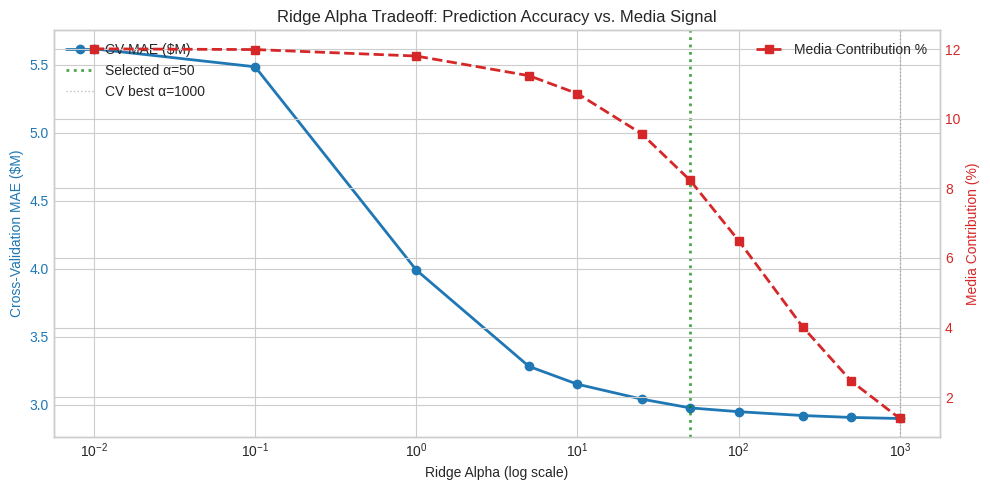

In [7]:
# Scale media features
scaler_2 = StandardScaler()
X2_scaled = scaler_2.fit_transform(X2)

# --- Cross-validate across a range of alphas ---
alphas = [0.01, 0.1, 1, 5, 10, 25, 50, 100, 250, 500, 1000]
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {}

for alpha in alphas:
    fold_scores = []
    for train_idx, test_idx in tscv.split(X2_scaled):
        ridge_cv = Ridge(alpha=alpha)
        ridge_cv.fit(X2_scaled[train_idx], residuals[train_idx])
        y_hat = ridge_cv.predict(X2_scaled[test_idx])
        mae = mean_absolute_error(residuals[test_idx], y_hat)
        fold_scores.append(mae)
    cv_scores[alpha] = np.mean(fold_scores)

# --- Also compute media contribution % for each alpha ---
# This shows the tradeoff: higher alpha = better MAE but lower media signal
alpha_sensitivity = []
for alpha in alphas:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(X2_scaled, residuals)
    coefs_tmp = ridge_tmp.coef_ / scaler_2.scale_
    
    total_eff = 0
    for i, ch in enumerate(CHANNELS):
        sat_col = f'{ch}_saturated'
        total_eff += coefs_tmp[i] * df[sat_col].sum()
    
    media_pct_tmp = total_eff / df[TARGET].sum() * 100
    alpha_sensitivity.append({
        'Alpha': alpha,
        'CV MAE ($)': cv_scores[alpha],
        'Media %': media_pct_tmp,
    })

sens_alpha_df = pd.DataFrame(alpha_sensitivity)

# --- Elbow detection: find where MAE improvement drops below 2% per step ---
# The idea: big improvements matter, tiny ones just kill signal
mae_values = [cv_scores[a] for a in alphas]
elbow_alpha = alphas[0]
for i in range(1, len(alphas)):
    improvement_pct = (mae_values[i-1] - mae_values[i]) / mae_values[i-1] * 100
    if improvement_pct < 2.0:  # Less than 2% improvement = diminishing returns
        elbow_alpha = alphas[i-1]
        break
else:
    elbow_alpha = alphas[-1]

# Use the elbow alpha
best_alpha = elbow_alpha
cv_best = min(cv_scores, key=cv_scores.get)

print("ALPHA SENSITIVITY: Prediction Error vs. Media Signal")
print("=" * 65)
print(f"{'Alpha':>8} {'CV MAE ($)':>14} {'MAE Δ%':>8} {'Media %':>10} {'Note':>12}")
print("-" * 65)
prev_mae = None
for _, row in sens_alpha_df.iterrows():
    a = row['Alpha']
    mae = row['CV MAE ($)']
    mp = row['Media %']
    delta = f"{(prev_mae - mae) / prev_mae * 100:.1f}%" if prev_mae else "—"
    
    note = ""
    if a == best_alpha:
        note = "← SELECTED"
    elif a == cv_best:
        note = "(CV best)"
    
    print(f"{a:>8.1f} ${mae:>13,.0f} {delta:>8} {mp:>9.1f}% {note:>12}")
    prev_mae = mae

print(f"\nCV would pick alpha={cv_best} (lowest MAE)")
print(f"We pick alpha={best_alpha} (elbow — MAE improvement < 2% beyond this point)")
print(f"This preserves the media signal while still regularizing against overfitting.")

# --- Fit final Stage 2 model ---
stage2 = Ridge(alpha=best_alpha)
stage2.fit(X2_scaled, residuals)

y_pred_s2 = stage2.predict(X2_scaled)
r2_s2 = r2_score(residuals, y_pred_s2)

# Combined fit
y_pred_full = y_pred_s1 + y_pred_s2
r2_full = r2_score(y, y_pred_full)

print(f"\n{'='*60}")
print(f"Stage 2 Results (alpha={best_alpha})")
print(f"{'='*60}")
print(f"  Stage 1 R² (seasonality): {r2_s1:.3f}")
print(f"  Stage 2 R² (media on residuals): {r2_s2:.3f}")
print(f"  Combined R² (full model): {r2_full:.3f}")

# Show standardized coefficients
print(f"\nStandardized Coefficients (Ridge, alpha={best_alpha}):")
print(f"{'Channel':<25} {'Coef (std)':>12} {'Sign':>6}")
print("-" * 46)
for i, ch_name in enumerate(X2.columns):
    coef = stage2.coef_[i]
    sign = '+' if coef >= 0 else '−'
    print(f"{ch_name:<25} {coef:>12,.0f} {sign:>6}")

# --- Visual: alpha tradeoff ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.semilogx(sens_alpha_df['Alpha'], sens_alpha_df['CV MAE ($)'] / 1e6, 
             'o-', color='tab:blue', label='CV MAE ($M)', linewidth=2)
ax1.set_xlabel('Ridge Alpha (log scale)')
ax1.set_ylabel('Cross-Validation MAE ($M)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.semilogx(sens_alpha_df['Alpha'], sens_alpha_df['Media %'], 
             's--', color='tab:red', label='Media Contribution %', linewidth=2)
ax2.set_ylabel('Media Contribution (%)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Mark selected alpha
ax1.axvline(best_alpha, color='green', linestyle=':', linewidth=2, alpha=0.7, label=f'Selected α={best_alpha}')
ax1.axvline(cv_best, color='gray', linestyle=':', linewidth=1, alpha=0.5, label=f'CV best α={cv_best}')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Ridge Alpha Tradeoff: Prediction Accuracy vs. Media Signal')
plt.tight_layout()
plt.savefig(fig_dir / '06c_alpha_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 8 — Convert to ROAS and Media Contribution

The Ridge coefficients are in "standardized" space (because we scaled the data before fitting). This cell converts them back to real dollars:

- **Coefficient (original)**: for each unit increase in saturated spend, how many dollars of revenue?
- **Total Media Effect**: coefficient × total saturated spend over 3 years = total revenue attributable to that channel
- **ROAS**: total media-driven revenue ÷ total raw spend = dollars of revenue per dollar spent
- **Media Contribution %**: total media effect across all channels ÷ total revenue = what share of revenue is attributable to media

This is the main output table — the one we'd show to the client.

In [8]:
# Back-transform: β_orig = β_std / scale (StandardScaler)
coefs_original = stage2.coef_ / scaler_2.scale_
intercept_s2 = stage2.intercept_ - np.dot(stage2.coef_, scaler_2.mean_ / scaler_2.scale_)

# Compute media contribution and ROAS for each channel
results = []
total_media_effect = 0

for i, ch in enumerate(CHANNELS):
    label = CHANNEL_LABELS[ch]
    beta_orig = coefs_original[i]
    
    # Media effect = β × saturated_spend (summed over all months)
    saturated_col = f'{ch}_saturated'
    media_effect_total = beta_orig * df[saturated_col].sum()
    
    # ROAS = total media-driven revenue / total raw spend
    total_raw_spend = df[ch].sum()
    roas = media_effect_total / total_raw_spend if total_raw_spend > 0 else 0
    
    # Monthly averages
    avg_monthly_spend = df[ch].mean()
    avg_monthly_effect = media_effect_total / n
    
    total_media_effect += media_effect_total
    
    results.append({
        'Channel': label,
        'Coef (original)': beta_orig,
        'Total Spend ($)': total_raw_spend,
        'Avg Monthly Spend ($)': avg_monthly_spend,
        'Total Media Effect ($)': media_effect_total,
        'ROAS': roas,
    })

results_df = pd.DataFrame(results)

# Media contribution %
total_revenue = df[TARGET].sum()
media_pct = total_media_effect / total_revenue * 100

print(f"{'='*80}")
print(f"MEDIA EFFECTIVENESS SUMMARY")
print(f"{'='*80}")
print(f"{'Channel':<22} {'Spend ($K)':>10} {'Effect ($K)':>12} {'ROAS':>8} {'% Rev':>8}")
print("-" * 64)
for _, row in results_df.iterrows():
    pct = row['Total Media Effect ($)'] / total_revenue * 100
    print(f"{row['Channel']:<22} {row['Total Spend ($)']/1e3:>10,.0f} "
          f"{row['Total Media Effect ($)']/1e3:>12,.0f} {row['ROAS']:>8.1f} {pct:>7.1f}%")

print("-" * 64)
total_spend = df['spend_total'].sum()
print(f"{'TOTAL':<22} {total_spend/1e3:>10,.0f} {total_media_effect/1e3:>12,.0f} "
      f"{total_media_effect/total_spend:>8.1f} {media_pct:>7.1f}%")
print(f"\nTotal 3Y Revenue: ${total_revenue/1e6:,.1f}M")
print(f"Total 3Y Media Spend: ${total_spend/1e6:,.1f}M")
print(f"Media Contribution: {media_pct:.1f}% of revenue")
print(f"Baseline (season+weather): {100 - media_pct:.1f}% of revenue")

MEDIA EFFECTIVENESS SUMMARY
Channel                Spend ($K)  Effect ($K)     ROAS    % Rev
----------------------------------------------------------------
Television                  3,949       12,943      3.3     2.5%
Radio                       2,167      -11,382     -5.3    -2.2%
Panneaux (DOOH)               292        2,233      7.6     0.4%
Social Media                  827       11,546     14.0     2.3%
Preroll (Video)               902       16,869     18.7     3.3%
Web Banners                   828        9,700     11.7     1.9%
Digital Flyers                447          278      0.6     0.1%
----------------------------------------------------------------
TOTAL                       9,413       42,187      4.5     8.2%

Total 3Y Revenue: $512.4M
Total 3Y Media Spend: $9.4M
Media Contribution: 8.2% of revenue
Baseline (season+weather): 91.8% of revenue


---
## Cell 9 — Bootstrap: How Confident Are We?

With only 36 months of data, any single estimate could be off. So we test how stable the results are:

- We resample the 36 months 1,000 times (randomly picking months with replacement, so some repeat and some are left out)
- Each time, we re-run the entire two-stage model from scratch
- This gives us 1,000 different ROAS estimates per channel
- The 90% confidence interval = the range that contains 90% of those estimates
- If the CI **doesn't cross zero**, we're fairly confident the channel actually drives revenue (marked "YES")
- If the CI **does cross zero**, we can't rule out that the channel has no effect — could be noise

In [9]:
np.random.seed(42)
N_BOOT = 1000

# Store bootstrap ROAS for each channel
boot_roas = {label: [] for label in CHANNEL_LABELS.values()}
boot_media_pct = []

for b in range(N_BOOT):
    # Resample indices (with replacement)
    idx = np.random.choice(n, size=n, replace=True)
    
    # Re-fit Stage 1
    s1_b = LinearRegression()
    s1_b.fit(X1_scaled[idx], y[idx])
    resid_b = y[idx] - s1_b.predict(X1_scaled[idx])
    
    # Re-fit Stage 2
    s2_b = Ridge(alpha=best_alpha)
    s2_b.fit(X2_scaled[idx], resid_b)
    
    # Back-transform coefficients
    coefs_b = s2_b.coef_ / scaler_2.scale_
    
    # Compute ROAS for each channel
    total_media_b = 0
    for i, ch in enumerate(CHANNELS):
        label = CHANNEL_LABELS[ch]
        sat_col = f'{ch}_saturated'
        effect_b = coefs_b[i] * df[sat_col].sum()
        spend_b = df[ch].sum()
        roas_b = effect_b / spend_b if spend_b > 0 else 0
        boot_roas[label].append(roas_b)
        total_media_b += effect_b
    
    boot_media_pct.append(total_media_b / total_revenue * 100)

# Compute 90% CIs
print(f"{'='*80}")
print(f"BOOTSTRAP CONFIDENCE INTERVALS (90% CI, {N_BOOT} resamples)")
print(f"{'='*80}")
print(f"{'Channel':<22} {'ROAS':>8} {'CI Low':>8} {'CI High':>8} {'Significant?':>14}")
print("-" * 64)

ci_results = []
for _, row in results_df.iterrows():
    label = row['Channel']
    roas_arr = np.array(boot_roas[label])
    ci_lo = np.percentile(roas_arr, 5)
    ci_hi = np.percentile(roas_arr, 95)
    sig = "YES" if ci_lo > 0 else "no"
    print(f"{label:<22} {row['ROAS']:>8.1f} {ci_lo:>8.1f} {ci_hi:>8.1f} {sig:>14}")
    ci_results.append({'Channel': label, 'ROAS': row['ROAS'], 'CI_Low': ci_lo, 'CI_High': ci_hi, 'Significant': sig})

mp_lo = np.percentile(boot_media_pct, 5)
mp_hi = np.percentile(boot_media_pct, 95)
print("-" * 64)
print(f"{'Media Contribution %':<22} {media_pct:>8.1f} {mp_lo:>8.1f} {mp_hi:>8.1f}")

ci_df = pd.DataFrame(ci_results)

BOOTSTRAP CONFIDENCE INTERVALS (90% CI, 1000 resamples)
Channel                    ROAS   CI Low  CI High   Significant?
----------------------------------------------------------------
Television                  3.3     -0.0      5.4             no
Radio                      -5.3     -7.8     -0.4             no
Panneaux (DOOH)             7.6    -10.2     22.2             no
Social Media               14.0    -14.6     35.6             no
Preroll (Video)            18.7      1.8     30.9            YES
Web Banners                11.7     -3.6     25.2             no
Digital Flyers              0.6    -20.8     24.0             no
----------------------------------------------------------------
Media Contribution %        8.2      3.1     11.9


---
## Cell 10 — Diagnostics: Is the Model Behaving?

Three sanity checks before we trust the results:

- **VIF (Variance Inflation Factor)**: Do the media channels move together so much that the model can't tell them apart? VIF above 5 = problem, above 10 = serious problem
- **Durbin-Watson**: Do the errors follow a pattern over time? Should be around 2.0. Below 1.5 means the residuals are autocorrelated (the model is systematically missing something)
- **Shapiro-Wilk**: Are the residuals roughly bell-shaped? If not, some of our confidence intervals might be off

The three charts show: actual vs. predicted, residuals over time, and a Q-Q plot (dots should follow the red line if residuals are normal).

MULTICOLLINEARITY CHECK (VIF)
Rule: VIF > 5 = high collinearity, VIF > 10 = severe
--------------------------------------------------
  Television                VIF = 4.8
  Radio                     VIF = 2.5
  Panneaux (DOOH)           VIF = 1.2
  Social Media              VIF = 2.5
  Preroll (Video)           VIF = 3.0
  Web Banners               VIF = 2.4
  Digital Flyers            VIF = 2.6

RESIDUAL AUTOCORRELATION
  Durbin-Watson = 2.19  (ideal ≈ 2.0; < 1.5 = positive autocorrelation)

RESIDUAL NORMALITY
  Shapiro-Wilk p-value = 0.7206  (Normal)


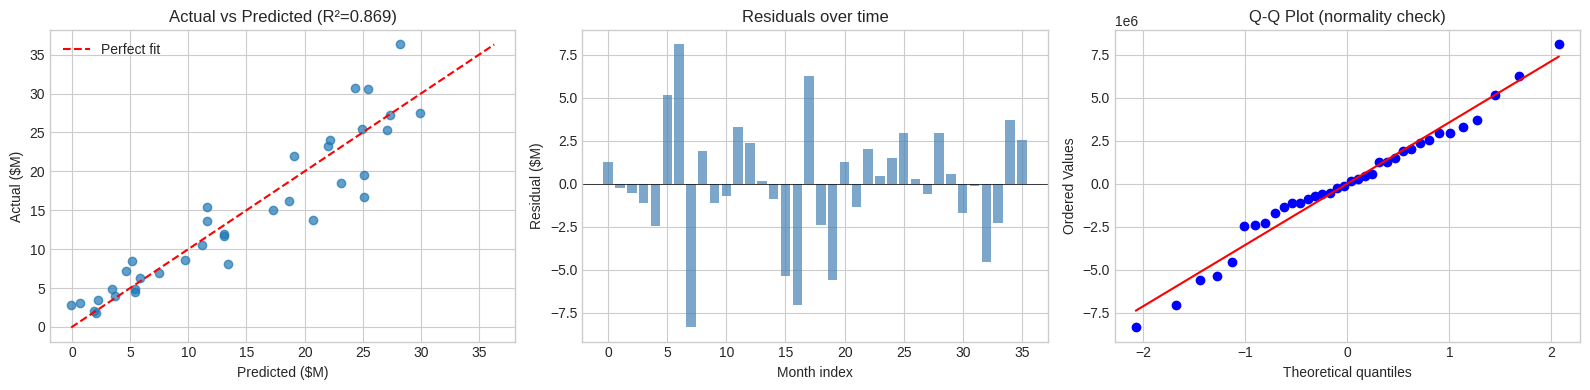

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

# --- VIF (Variance Inflation Factor) ---
print("MULTICOLLINEARITY CHECK (VIF)")
print("Rule: VIF > 5 = high collinearity, VIF > 10 = severe")
print("-" * 50)
vif_data = X2.copy()
vif_data = vif_data.assign(const=1)  # Add constant for VIF calc
for i, col in enumerate(X2.columns):
    vif = variance_inflation_factor(vif_data.values, i)
    flag = " ⚠ HIGH" if vif > 5 else ""
    print(f"  {col:<25} VIF = {vif:.1f}{flag}")

# --- Durbin-Watson ---
final_residuals = y - y_pred_full
dw = durbin_watson(final_residuals)
print(f"\nRESIDUAL AUTOCORRELATION")
print(f"  Durbin-Watson = {dw:.2f}  (ideal ≈ 2.0; < 1.5 = positive autocorrelation)")

# --- Shapiro-Wilk ---
sw_stat, sw_p = stats.shapiro(final_residuals)
print(f"\nRESIDUAL NORMALITY")
print(f"  Shapiro-Wilk p-value = {sw_p:.4f}  ({'Normal' if sw_p > 0.05 else 'Non-normal'})")

# --- Residual plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actual vs Predicted
axes[0].scatter(y_pred_full / 1e6, y / 1e6, alpha=0.7)
mn, mx = min(y.min(), y_pred_full.min()) / 1e6, max(y.max(), y_pred_full.max()) / 1e6
axes[0].plot([mn, mx], [mn, mx], 'r--', label='Perfect fit')
axes[0].set_xlabel('Predicted ($M)')
axes[0].set_ylabel('Actual ($M)')
axes[0].set_title(f'Actual vs Predicted (R²={r2_full:.3f})')
axes[0].legend()

# Residuals over time
axes[1].bar(range(n), final_residuals / 1e6, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Month index')
axes[1].set_ylabel('Residual ($M)')
axes[1].set_title('Residuals over time')

# Q-Q plot
stats.probplot(final_residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normality check)')

plt.tight_layout()
plt.savefig(fig_dir / '06c_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 11 — Sensitivity: What If We Change the TV Decay Rate?

The TV decay rate is the single most impactful parameter choice in the whole model. So let's be transparent about it:

- NB06 used λ=0.2 (TV effect fades in ~2 weeks). We changed it to λ=0.5 (~1.4 months). Industry papers suggest λ=0.5–0.9 for brand TV
- This table shows what happens to TV's ROAS and total media contribution as we vary λ from 0.2 to 0.8
- The point: results are sensitive to this assumption. When presenting to the client, we should be upfront about this — it's not a flaw, it's just the reality of modeling with limited data

TV DECAY RATE SENSITIVITY ANALYSIS
  TV λ    TV ROAS    Media %
------------------------------
   0.2        4.3       8.0% ← NB06
   0.3        4.0       8.0%
   0.4        3.7       8.1%
   0.5        3.3       8.2% ← base
   0.6        2.9       8.5%
   0.7        2.6       8.8%
   0.8        2.3       9.3%


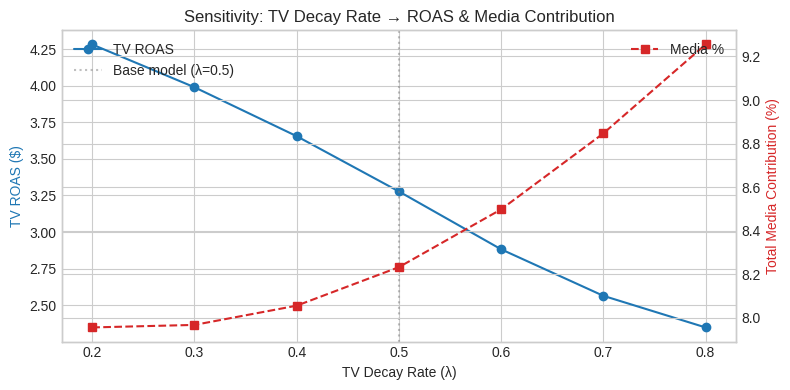

In [11]:
tv_lambdas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sensitivity_results = []

for tv_lam in tv_lambdas:
    # Re-apply adstock with new TV lambda
    df_sens = df.copy()
    for ch in CHANNELS:
        lam = tv_lam if ch == 'spend_television' else DECAY_RATES[ch]
        df_sens[f'{ch}_adstock'] = geometric_adstock(df_sens[ch].fillna(0).values, lam)
    
    # Re-compute K and saturation
    for ch in CHANNELS:
        max_ads = df_sens[f'{ch}_adstock'].max()
        K = K_FRACTION * max_ads
        df_sens[f'{ch}_saturated'] = hill_saturation(df_sens[f'{ch}_adstock'].values, K, SATURATION_ALPHA)
    
    # Build X2 and re-fit
    X2_s = df_sens[[f'{ch}_saturated' for ch in CHANNELS]].values
    sc2 = StandardScaler()
    X2_s_scaled = sc2.fit_transform(X2_s)
    
    ridge_s = Ridge(alpha=best_alpha)
    ridge_s.fit(X2_s_scaled, residuals)
    coefs_s = ridge_s.coef_ / sc2.scale_
    
    # TV ROAS
    tv_idx = CHANNELS.index('spend_television')
    tv_effect = coefs_s[tv_idx] * df_sens['spend_television_saturated'].sum()
    tv_spend = df['spend_television'].sum()
    tv_roas = tv_effect / tv_spend if tv_spend > 0 else 0
    
    # Total media %
    total_eff = sum(coefs_s[j] * df_sens[f'{CHANNELS[j]}_saturated'].sum() for j in range(len(CHANNELS)))
    media_p = total_eff / total_revenue * 100
    
    sensitivity_results.append({
        'TV λ': tv_lam, 'TV ROAS': tv_roas, 'Media %': media_p
    })

sens_df = pd.DataFrame(sensitivity_results)

print("TV DECAY RATE SENSITIVITY ANALYSIS")
print("=" * 45)
print(f"{'TV λ':>6} {'TV ROAS':>10} {'Media %':>10}")
print("-" * 30)
for _, row in sens_df.iterrows():
    marker = " ← base" if row['TV λ'] == 0.5 else (" ← NB06" if row['TV λ'] == 0.2 else "")
    print(f"{row['TV λ']:>6.1f} {row['TV ROAS']:>10.1f} {row['Media %']:>9.1f}%{marker}")

# Plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(sens_df['TV λ'], sens_df['TV ROAS'], 'o-', color='tab:blue', label='TV ROAS')
ax1.set_xlabel('TV Decay Rate (λ)')
ax1.set_ylabel('TV ROAS ($)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(sens_df['TV λ'], sens_df['Media %'], 's--', color='tab:red', label='Media %')
ax2.set_ylabel('Total Media Contribution (%)', color='tab:red')
ax1.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Base model (λ=0.5)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Sensitivity: TV Decay Rate → ROAS & Media Contribution')
plt.tight_layout()
plt.savefig(fig_dir / '06c_tv_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 12 — Save Results

- Exports the final results table to CSV (for reports) and JSON (for the NB07 optimizer)
- These files go into `data/processed/` so other notebooks can pick them up

In [12]:
import json

# --- Final summary table ---
summary = results_df.merge(ci_df[['Channel', 'CI_Low', 'CI_High', 'Significant']], on='Channel')

print("\n" + "=" * 90)
print("06C BASE MODEL — FINAL RESULTS")
print("=" * 90)
print(f"\nModel: Two-Stage Ridge Regression")
print(f"  Stage 1: Fourier seasonality + weather → R² = {r2_s1:.3f}")
print(f"  Stage 2: 7 media channels (adstock + Hill saturation) → R² = {r2_s2:.3f}")
print(f"  Combined R² = {r2_full:.3f}")
print(f"  Ridge alpha = {best_alpha}")
print(f"  Bootstrap: {N_BOOT} resamples, 90% CI")
print(f"  Observations: {n} months")
print(f"\nMedia Contribution: {media_pct:.1f}% of revenue (90% CI: {mp_lo:.1f}% — {mp_hi:.1f}%)")
print(f"Total Revenue (3Y): ${total_revenue/1e6:.1f}M")
print(f"Total Spend (3Y): ${total_spend/1e6:.1f}M")
print()
print(summary.to_string(index=False))

# --- Save results ---
output_dir = data_dir

# CSV
summary.to_csv(output_dir / 'model_06c_results.csv', index=False)
print(f"\nSaved: {output_dir / 'model_06c_results.csv'}")

# JSON (for NB07 optimizer)
model_params = {
    'model_version': '06C_base',
    'r2_full': round(r2_full, 4),
    'r2_stage1': round(r2_s1, 4),
    'r2_stage2': round(r2_s2, 4),
    'ridge_alpha': best_alpha,
    'n_observations': n,
    'media_contribution_pct': round(media_pct, 2),
    'media_contribution_ci': [round(mp_lo, 2), round(mp_hi, 2)],
    'channels': {},
    'decay_rates': {CHANNEL_LABELS[ch]: DECAY_RATES[ch] for ch in CHANNELS},
    'saturation_K': {CHANNEL_LABELS[ch]: round(K_VALUES[ch], 2) for ch in CHANNELS},
}

for _, row in summary.iterrows():
    model_params['channels'][row['Channel']] = {
        'coef_original': round(row['Coef (original)'], 4),
        'total_spend': round(row['Total Spend ($)'], 2),
        'total_effect': round(row['Total Media Effect ($)'], 2),
        'roas': round(row['ROAS'], 2),
        'ci_low': round(row['CI_Low'], 2),
        'ci_high': round(row['CI_High'], 2),
        'significant': row['Significant'] == 'YES',
    }

with open(output_dir / 'model_06c_params.json', 'w') as f:
    json.dump(model_params, f, indent=2)
print(f"Saved: {output_dir / 'model_06c_params.json'}")


06C BASE MODEL — FINAL RESULTS

Model: Two-Stage Ridge Regression
  Stage 1: Fourier seasonality + weather → R² = 0.849
  Stage 2: 7 media channels (adstock + Hill saturation) → R² = 0.134
  Combined R² = 0.869
  Ridge alpha = 50
  Bootstrap: 1000 resamples, 90% CI
  Observations: 36 months

Media Contribution: 8.2% of revenue (90% CI: 3.1% — 11.9%)
Total Revenue (3Y): $512.4M
Total Spend (3Y): $9.4M

        Channel  Coef (original)  Total Spend ($)  Avg Monthly Spend ($)  Total Media Effect ($)      ROAS     CI_Low   CI_High Significant
     Television     1.914868e+06     3.948951e+06          109693.090000            1.294290e+07  3.277553  -0.016164  5.443502          no
          Radio    -1.108631e+06     2.167277e+06           60202.128529           -1.138179e+07 -5.251658  -7.766668 -0.381448          no
Panneaux (DOOH)     6.527690e+05     2.924950e+05            8124.861772            2.233129e+06  7.634758 -10.220399 22.240204          no
   Social Media     9.741184e+05  

---
## Cell 13 — Charts

- Left chart: ROAS per channel with confidence intervals. Green = statistically significant, grey = uncertain. The black bars show the 90% CI range
- Right chart: How much we spent vs. how much revenue the model attributes to each channel

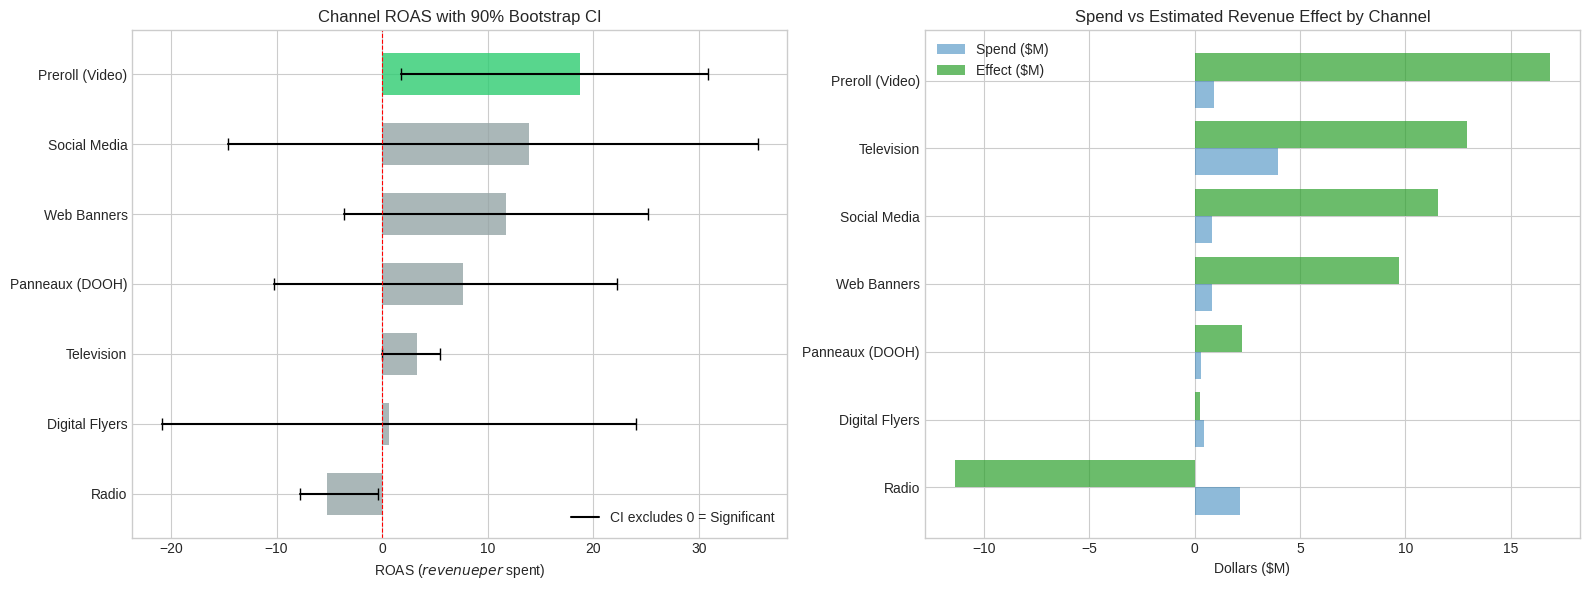

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ROAS bar chart with CIs ---
channels_sorted = ci_df.sort_values('ROAS', ascending=True)
colors = ['#2ecc71' if s == 'YES' else '#95a5a6' for s in channels_sorted['Significant']]

y_pos = range(len(channels_sorted))
axes[0].barh(y_pos, channels_sorted['ROAS'], color=colors, alpha=0.8, height=0.6)

# Error bars for CI
for i, (_, row) in enumerate(channels_sorted.iterrows()):
    axes[0].plot([row['CI_Low'], row['CI_High']], [i, i], 'k-', linewidth=1.5)
    axes[0].plot([row['CI_Low'], row['CI_High']], [i, i], 'k|', markersize=8)

axes[0].axvline(0, color='red', linewidth=0.8, linestyle='--')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(channels_sorted['Channel'])
axes[0].set_xlabel('ROAS ($ revenue per $ spent)')
axes[0].set_title('Channel ROAS with 90% Bootstrap CI')
axes[0].legend(['CI excludes 0 = Significant'], loc='lower right')

# --- Spend vs Effect waterfall ---
ax2 = axes[1]
channels_by_effect = results_df.sort_values('Total Media Effect ($)', ascending=True)
y_pos2 = range(len(channels_by_effect))

bars_spend = ax2.barh(y_pos2, channels_by_effect['Total Spend ($)'] / 1e6, 
                       alpha=0.5, color='tab:blue', label='Spend ($M)', height=0.4)
bars_effect = ax2.barh([p + 0.4 for p in y_pos2], 
                        channels_by_effect['Total Media Effect ($)'] / 1e6,
                        alpha=0.7, color='tab:green', label='Effect ($M)', height=0.4)

ax2.set_yticks([p + 0.2 for p in y_pos2])
ax2.set_yticklabels(channels_by_effect['Channel'])
ax2.set_xlabel('Dollars ($M)')
ax2.set_title('Spend vs Estimated Revenue Effect by Channel')
ax2.legend()

plt.tight_layout()
plt.savefig(fig_dir / '06c_roas_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Limitations & What's Next

**What this base model does well:**
- Clean separation of "seasonal demand" vs. "media-driven demand"
- Honest estimates — no tricks to force results to look good
- Confidence intervals so we know what we're sure about vs. what's uncertain
- TV decay corrected based on the client's own media strategy narrative

**What it doesn't do yet (and we can add later):**
- **Only 36 months of data** — weekly data exists (156 weeks) and would improve precision significantly
- **No interaction effects** — TV's "halo" on digital channels isn't captured. Adding TV × Digital terms could reveal synergies
- **Fixed transformation parameters** — the decay rates and saturation curves are set by us, not learned from data. A Bayesian approach could estimate them jointly
- **One weather point** — province-wide average for 42 stores spread across Quebec
- **Total revenue only** — different product categories (pools vs. furniture vs. spas) might respond to media differently

**Next steps (to discuss):**
- Walk through these results together — which channels do we trust? which do we question?
- Decide what to add first: interaction terms? weekly data? category breakdowns?
- Feed the coefficients into NB07 for budget optimization scenarios